In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce GTX 1650


In [3]:
def corrupt_image(img):

    def noise(i):
        return np.clip(i + np.random.normal(0,20,i.shape),0,255).astype(np.uint8)

    def blur(i):
        return cv2.GaussianBlur(i,(5,5),0)

    def lowres(i):
        h,w = i.shape[:2]
        small = cv2.resize(i,(w//3,h//3))
        return cv2.resize(small,(w,h))

    return random.choice([noise, blur, lowres])(img)

In [4]:
class UnsupervisedDataset(Dataset):

    def __init__(self, root_dir, img_size=224):

        self.paths = [os.path.join(root_dir,f)
                      for f in os.listdir(root_dir)]

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size,img_size))
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        corrupted = corrupt_image(img.copy())

        corrupted = self.transform(corrupted)

        return corrupted

In [5]:
DATA_PATH = r"D:\Image Recognition\data"

dataset = UnsupervisedDataset(DATA_PATH)

loader = DataLoader(dataset,
                    batch_size=8,
                    shuffle=True)

print("Dataset size:", len(dataset))

Dataset size: 3000


In [6]:
class Block(nn.Module):

    def __init__(self,a,b):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(a,b,3,1,1),
            nn.BatchNorm2d(b),
            nn.ReLU()
        )

    def forward(self,x):
        return self.net(x)


class ProcessingNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            Block(3,64),
            Block(64,64),

            nn.MaxPool2d(2),

            Block(64,128),
            Block(128,128),

            nn.Upsample(scale_factor=2),

            Block(128,64),

            nn.Conv2d(64,3,3,1,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [7]:
model = ProcessingNet().to(device)

In [8]:
teacher = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

teacher = teacher.to(device)
teacher.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
normalize = transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225]
)   

In [10]:
normalize = transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225]
)

In [11]:
consistency_loss = nn.MSELoss()
entropy_loss = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

lambda_recog = 0.1

In [12]:
EPOCHS = 10

for epoch in range(EPOCHS):

    epoch_loss = 0

    pbar = tqdm(loader)

    for corrupted in pbar:

        corrupted = corrupted.to(device)

        restored = model(corrupted)

        # consistency (output should not deviate too much)
        loss_consistency = consistency_loss(restored, corrupted)

        # teacher predictions
        with torch.no_grad():
            teacher_pred = teacher(normalize(corrupted))
            labels = teacher_pred.argmax(1)

        pred = teacher(normalize(restored))

        loss_recog = entropy_loss(pred, labels)

        loss = loss_consistency + lambda_recog * loss_recog

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        pbar.set_postfix(
            consistency=loss_consistency.item(),
            recog=loss_recog.item(),
            total=loss.item()
        )

    print("Epoch", epoch+1,
          "Loss:", epoch_loss/len(loader))

100%|██████████| 375/375 [03:55<00:00,  1.60it/s, consistency=0.00667, recog=1.35, total=0.142]  


Epoch 1 Loss: 0.25586780498425166


100%|██████████| 375/375 [03:26<00:00,  1.82it/s, consistency=0.00451, recog=1.69, total=0.173]  


Epoch 2 Loss: 0.17802695175011954


100%|██████████| 375/375 [03:22<00:00,  1.86it/s, consistency=0.00418, recog=1.55, total=0.16]   


...

Epoch 8 Loss: 0.15016356561581293


100%|██████████| 375/375 [03:31<00:00,  1.77it/s, consistency=0.00418, recog=1.35, total=0.139]  


Epoch 9 Loss: 0.1470766507188479


100%|██████████| 375/375 [03:32<00:00,  1.77it/s, consistency=0.00441, recog=1.38, total=0.142]  

Epoch 10 Loss: 0.14550302958488465


In [13]:
torch.save(model.state_dict(),
           "unsupervised_RA_model.pth")

print("Model saved")

Model saved


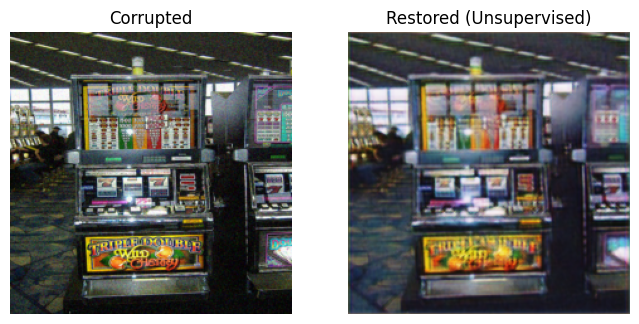

In [14]:
sample = next(iter(loader))

sample = sample.to(device)

with torch.no_grad():
    restored = model(sample).cpu()

def show(img):

    img = img.permute(1,2,0).numpy()
    img = np.clip(img,0,1)

    plt.imshow(img)
    plt.axis("off")

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
show(sample[0].cpu())
plt.title("Corrupted")

plt.subplot(1,2,2)
show(restored[0])
plt.title("Restored (Unsupervised)")

plt.show()